In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Cargar variables del .env
load_dotenv('pg_credenciales.env')

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
consulta="""
SELECT table_name
FROM information_schema.tables
WHERE table_schema='gob_ciencia_y_tecnologia'

"""

pd.read_sql_query(consulta,con=engine)

tablas = pd.read_sql_query(consulta,con=engine)

In [3]:
display(tablas)

,table_name
0,proy_lab_nac_2025
1,publicaciones_arbitradas_2022
2,publicaciones_arbitradas_2023
3,publicaciones_arbitradas_2024
4,Publicaciones2024
5,resultados_con_inv_cient
6,proy_inve_cien_hum_2025
7,snii_s1_2025
8,snii_s2_2025


In [4]:
# Celda 2: Ver la estructura de cada tabla
for tabla in tablas['table_name']:
    print(f"\n{'='*60}")
    print(f"📋 ESTRUCTURA DE: {tabla}")
    print('='*60)
    
    # Obtener columnas y tipos de datos
    consulta_estructura = f"""
    SELECT 
        column_name,
        data_type,
        character_maximum_length,
        is_nullable
    FROM information_schema.columns 
    WHERE table_schema = 'gob_ciencia_y_tecnologia' 
      AND table_name = '{tabla}'
    ORDER BY ordinal_position;
    """
    
    estructura = pd.read_sql_query(consulta_estructura, con=engine)
    display(estructura)
    
    # Ver primeras 3 filas como ejemplo
    consulta_muestra = f"""
    SELECT * 
    FROM gob_ciencia_y_tecnologia."{tabla}" 
    LIMIT 3;
    """
    
    muestra = pd.read_sql_query(consulta_muestra, con=engine)
    print(f"\nPrimeras filas de {tabla}:")
    display(muestra)


📋 ESTRUCTURA DE: proy_lab_nac_2025


,column_name,data_type,character_maximum_length,is_nullable
0,fecha_publicacion_convocatoria,text,None,YES
1,programa_presupuestal,text,None,YES
2,anio_convocatoria,bigint,None,YES
3,fecha_aprobacion,text,None,YES
4,acuerdo_aprobacion,text,None,YES
5,clave_proyecto,text,None,YES
6,titulo_proyecto,text,None,YES
7,objetivo,text,None,YES
8,modalidad,text,None,YES
9,area_conocimiento,text,None,YES



Primeras filas de proy_lab_nac_2025:


,fecha_publicacion_convocatoria,programa_presupuestal,anio_convocatoria,fecha_aprobacion,acuerdo_aprobacion,clave_proyecto,titulo_proyecto,objetivo,modalidad,area_conocimiento,...,otras_instituciones_participantes,fecha_formalizacion,monto_aprobado,aportaciones_concurrentes,monto_total,monto_ministrado,monto_pendiente_ministrar,duracion_meses,etapas,estatus_proyecto
0,2025-03-10,F003,2025,2025-07-31,PP F003 7/XIV-E/2025,APOYOLN-2025-C-1,Anticipando Los Efectos del Cambio Climático: ...,Estimar Umbrales Críticos Para la Funcionalida...,Ii. Impulso a la Investigación Científica Bási...,1. Física-Matemática y Ciencias de la Tierra,...,1. Instituto de Ciencias de la Atmósfera y Cam...,2025-09-29,7486570.0,None,7486570.0,None,7486570.0,26,3,Formalizado
1,2025-03-10,F003,2025,2025-07-31,PP F003 7/XIV-E/2025,APOYOLN-2025-C-102,Laboratorio Nacional de Observación de la Tier...,Mantener la Operación del Laboratorio Nacional...,Ii. Impulso a la Investigación Científica Bási...,1. Física-Matemática y Ciencias de la Tierra,...,1. Instituto Nacional de Estadística y Geograf...,2025-10-03,7118000.0,None,7118000.0,None,7118000.0,26,3,Formalizado
2,2025-03-10,F003,2025,2025-07-31,PP F003 7/XIV-E/2025,APOYOLN-2025-C-110,Plataforma Tecnológica de Microfluídica Avanza...,Desarrollar Una Plataforma Tecnológica de Micr...,Ii. Impulso a la Investigación Científica Bási...,8. Ingenierías y Desarrollo Tecnologico,...,"1. Universidad Autónoma de Querétaro, Uaq 2. C...",2025-09-26,7500000.0,None,7500000.0,None,7500000.0,26,3,Formalizado



📋 ESTRUCTURA DE: publicaciones_arbitradas_2022


...

,cvu,nombre,apellido1,apellido2,nivel,categoria,inicio_vigencia,fin_vigencia,area_conocimiento,disciplina,subdisciplina,especialidad,institucion_acreditacion_comision,dependencia_acreditacion_comision,entidad_acreditacion_comision,posdoc_iixm,rec_apoyo_recibido,apoyo_umas,comentario
0,241640,Diecenia,Peralta,Dominguez,1,Sin Dato,2024-01-01,2028-12-31,Fisico-Matematicas y Ciencias de la Tierra,Ingenieria Fisica,Otras,Fisica,Centro de Investigacion y de Estudios Avanzado...,Unidad Merida,Yucatan,Estancias Posdoctorales,Reconocimiento y Apoyo,6,La Entrega del Estimulo Economico Esta Sujeto ...
1,343652,Jose,Ojeda,Bustamante,C,Sin Dato,2024-01-01,2027-12-31,Ciencias Sociales,Instituciones Politicas,Otras,Ciencia Politica,Universidad Autonoma de Guerrero,Sin Dato,Guerrero,Estancias Posdoctorales,Reconocimiento y Apoyo,3,La Entrega del Estimulo Economico Esta Sujeto ...
2,637370,Alejandro Miguel,Castañeda,Valencia,C,Sin Dato,2025-01-01,2028-12-31,Ciencias Sociales,Econometria,Modelos Econometricos,Ciencias Economicas,Colegio de Postgraduados,Campus Puebla,Puebla,Estancias Posdoctorales,Reconocimiento y Apoyo,3,La Entrega del Estimulo Economico Esta Sujeto ...



📋 ESTRUCTURA DE: snii_s2_2025


,column_name,data_type,character_maximum_length,is_nullable
0,cvu,bigint,None,YES
1,nombre,text,None,YES
2,apellido1,text,None,YES
3,apellido2,text,None,YES
4,nivel,text,None,YES
5,categoria,text,None,YES
6,inicio_vigencia,timestamp without time zone,None,YES
7,fin_vigencia,timestamp without time zone,None,YES
8,area_conocimiento,text,None,YES
9,disciplina,text,None,YES



Primeras filas de snii_s2_2025:


,cvu,nombre,apellido1,apellido2,nivel,categoria,inicio_vigencia,fin_vigencia,area_conocimiento,disciplina,subdisciplina,especialidad,institucion_acreditacion_comision,dependencia_acreditacion_comision,entidad_acreditacion_comision,posdoc_iixm,rec_apoyo_recibido,apoyo_umas,comentario
0,4,Jorge,Alonso,Sanchez,E,Emerito,2016-01-01,2099-12-31,Humanidades,Grupos Sociales,Otras,Sociologia,Centro de Investigaciones y Estudios Superiore...,Unidad Occidente,Jalisco,No,Reconocimiento y Apoyo,14,La Entrega del Estimulo Economico Esta Sujeto ...
1,5,Elena,Azaola,Garrido,E,Emerito,2019-01-01,2117-12-31,Humanidades,Antropologia Social,Otras,Antropologia,Centro de Investigaciones y Estudios Superiore...,Unidad - D.F.,Ciudad de Mexico,No,Reconocimiento y Apoyo,14,La Entrega del Estimulo Economico Esta Sujeto ...
2,18,Miguel Angel,Perez,Angon,3,Extension 15 Años,2022-01-01,2036-12-31,Fisico-Matematicas y Ciencias de la Tierra,Fisica de Altas Energias,Fisica Teorica Altas Energias,Fisica,Centro de Investigacion y de Estudios Avanzado...,Departamento de Fisica,Ciudad de Mexico,No,Reconocimiento y Apoyo,14,La Entrega del Estimulo Economico Esta Sujeto ...


In [5]:
#ANALISIS EXPLORATORIO 

#NUMERO DE REGISTROS POR TABLA
print("resumen de registros por tabla")
for tabla in tablas['table_name']:
    consulta_conteo=f'SELECT COUNT(*) as total FROM gob_ciencia_y_tecnologia."{tabla}" '
    resultado=pd.read_sql_query(consulta_conteo, con=engine)
    print(f"-{tabla}:{resultado['total'][0]:,} registros")

resumen de registros por tabla
-proy_lab_nac_2025:42 registros
-publicaciones_arbitradas_2022:51 registros
-publicaciones_arbitradas_2023:336 registros
-publicaciones_arbitradas_2024:37 registros
-Publicaciones2024:271 registros
-resultados_con_inv_cient:1,867 registros
-proy_inve_cien_hum_2025:723 registros
-snii_s1_2025:44,835 registros
-snii_s2_2025:44,794 registros


In [6]:
query_muestra=f' SELECT * FROM gob_ciencia_y_tecnologia."{tabla}" LIMIT 3'
muestra =pd.read_sql_query(query_muestra, con = engine)
print("Muestra de datos:")
display(muestra)

Muestra de datos:


,cvu,nombre,apellido1,apellido2,nivel,categoria,inicio_vigencia,fin_vigencia,area_conocimiento,disciplina,subdisciplina,especialidad,institucion_acreditacion_comision,dependencia_acreditacion_comision,entidad_acreditacion_comision,posdoc_iixm,rec_apoyo_recibido,apoyo_umas,comentario
0,4,Jorge,Alonso,Sanchez,E,Emerito,2016-01-01,2099-12-31,Humanidades,Grupos Sociales,Otras,Sociologia,Centro de Investigaciones y Estudios Superiore...,Unidad Occidente,Jalisco,No,Reconocimiento y Apoyo,14,La Entrega del Estimulo Economico Esta Sujeto ...
1,5,Elena,Azaola,Garrido,E,Emerito,2019-01-01,2117-12-31,Humanidades,Antropologia Social,Otras,Antropologia,Centro de Investigaciones y Estudios Superiore...,Unidad - D.F.,Ciudad de Mexico,No,Reconocimiento y Apoyo,14,La Entrega del Estimulo Economico Esta Sujeto ...
2,18,Miguel Angel,Perez,Angon,3,Extension 15 Años,2022-01-01,2036-12-31,Fisico-Matematicas y Ciencias de la Tierra,Fisica de Altas Energias,Fisica Teorica Altas Energias,Fisica,Centro de Investigacion y de Estudios Avanzado...,Departamento de Fisica,Ciudad de Mexico,No,Reconocimiento y Apoyo,14,La Entrega del Estimulo Economico Esta Sujeto ...


tablas con snii: ['snii_s1_2025', 'snii_s2_2025']
                                   area_conocimiento  cantidad  porcentaje
0                                 Biologia y Quimica      6909       15.41
1  Ciencias de Agricultura, Agropecuarias, Forest...      5459       12.18
2             Ciencias de la Conducta y la Educacion      2043        4.56
3                                  Ciencias Sociales      8518       19.00
4         Fisico-Matematicas y Ciencias de la Tierra      5766       12.86
5                                        Humanidades      5022       11.20
6               Ingenierias y Desarrollo Tecnologico      5072       11.31
7                                 Interdisciplinaria      1375        3.07
8                    Medicina y Ciencias de la Salud      4671       10.42


<Figure size 2000x1000 with 0 Axes>

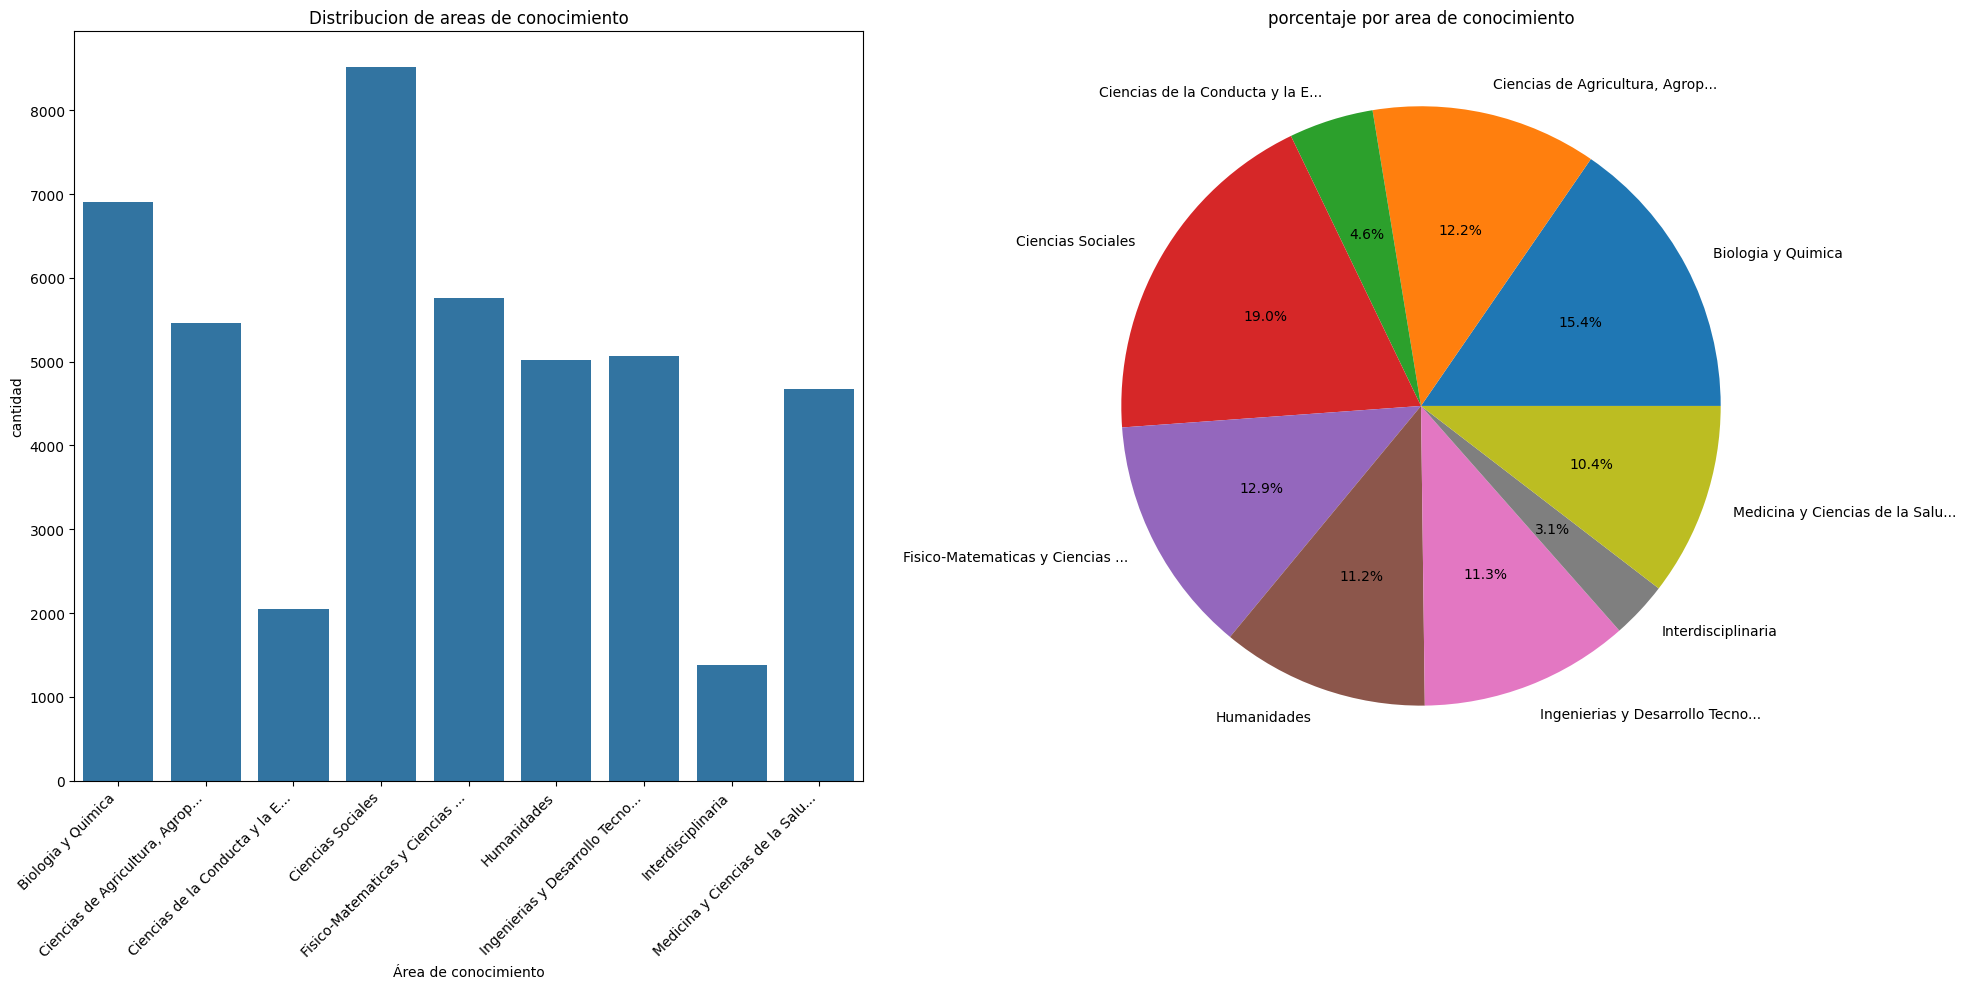

                                   area_conocimiento  cantidad  porcentaje
0                                 Biologia y Quimica      7186       16.04
1  Ciencias de Agricultura, Agropecuarias, Forest...      5207       11.62
2             Ciencias de la Conducta y la Educacion      2399        5.36
3                                  Ciencias Sociales      8458       18.88
4         Fisico-Matematicas y Ciencias de la Tierra      5795       12.94
5                                        Humanidades      4555       10.17
6               Ingenierias y Desarrollo Tecnologico      4849       10.83
7                                 Interdisciplinaria      1742        3.89
8                    Medicina y Ciencias de la Salud      4603       10.28


<Figure size 2000x1000 with 0 Axes>

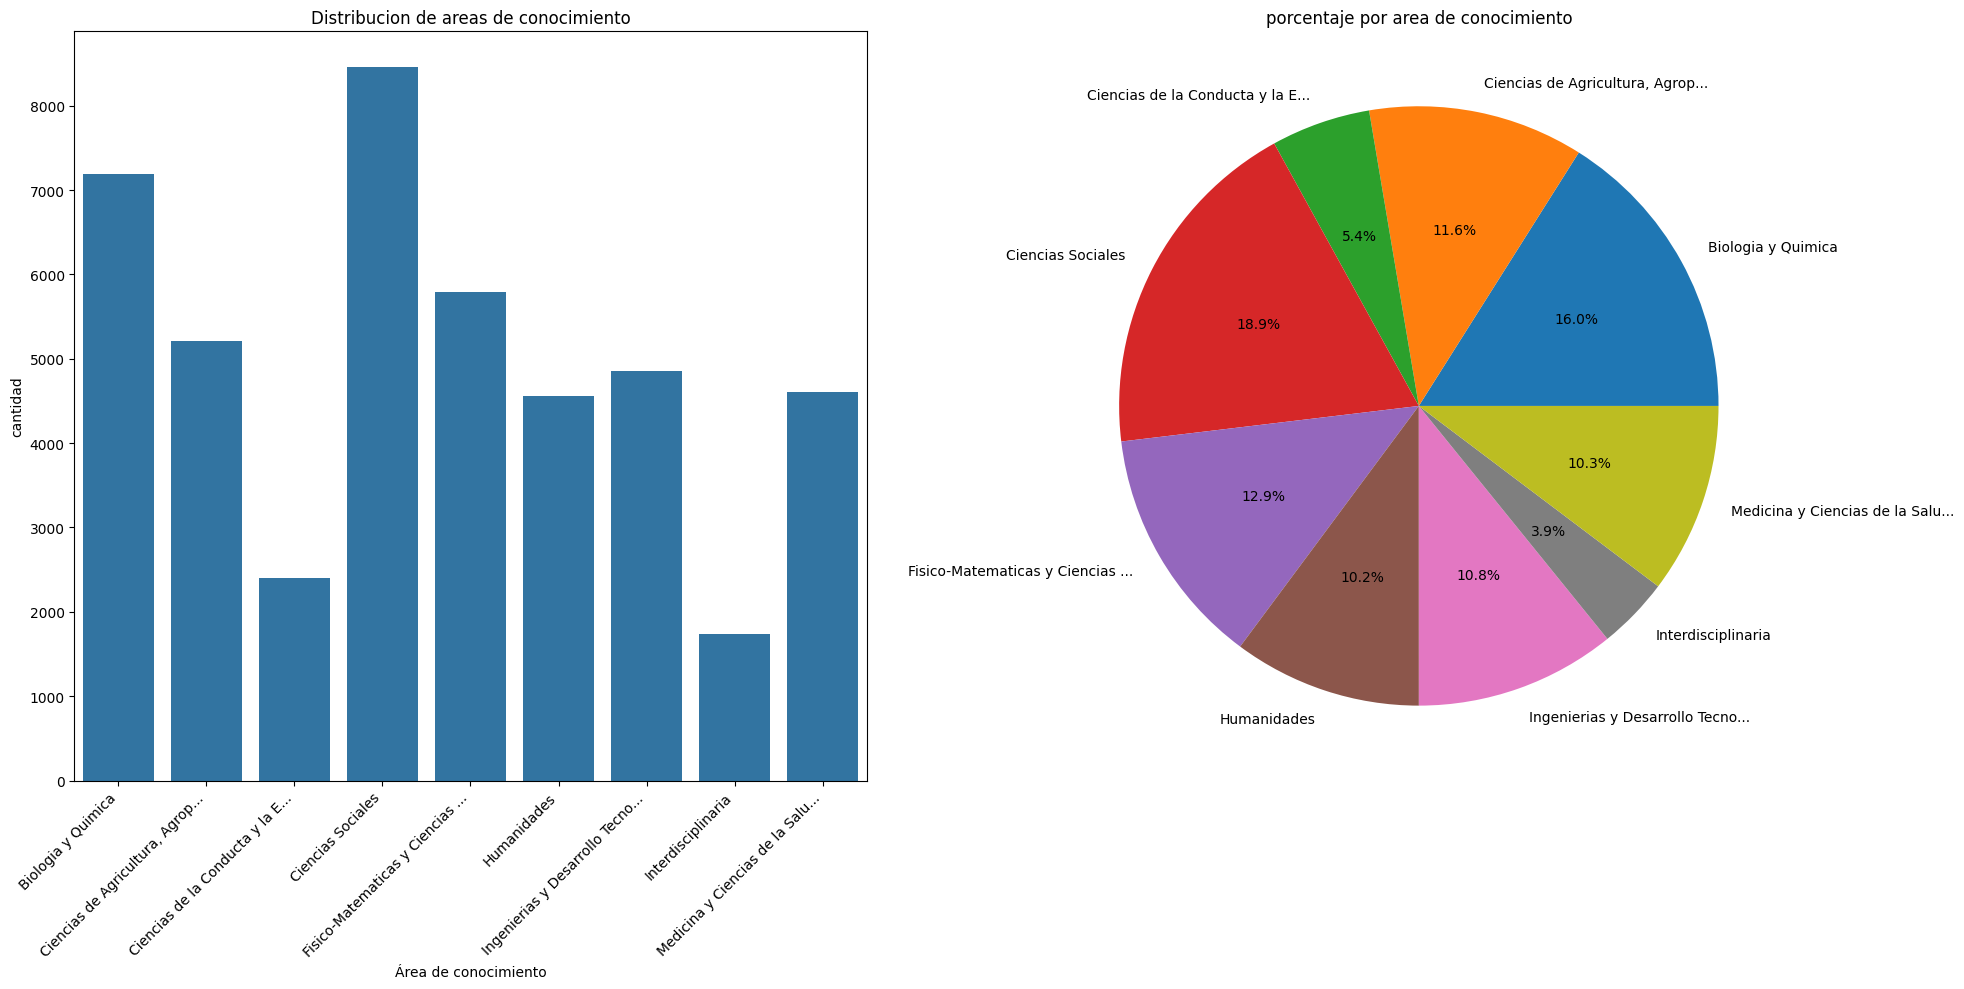

In [7]:
nombres_tablas=tablas['table_name'].tolist()
tablas_snii = [t for t in nombres_tablas if 'snii' in t.lower()]
print(f'tablas con snii: {tablas_snii}')


for tabla in tablas_snii:
    query = f"""
       SELECT area_conocimiento, 
            COUNT(*) AS cantidad,
            ROUND(100.0 * COUNT(*)/SUM(COUNT(*)) OVER(),2) AS porcentaje   
        FROM gob_ciencia_y_tecnologia.{tabla}
        
        GROUP BY area_conocimiento
        ORDER BY area_conocimiento
        """

    temp=pd.read_sql_query(query, con = engine)
    print(temp)

    labels_short = [label[:30] + '...' if len(label) > 20 else label for label in temp['area_conocimiento']]
    plt.figure(figsize=(20,10))

    temp_short = temp.copy()
    temp_short['area_conocimiento_short'] = labels_short

    plt.figure(figsize=(20,10))

    plt.subplot(1,2,1)
    sns.barplot(x='area_conocimiento_short', y='cantidad', data=temp_short)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Área de conocimiento')
    plt.title("Distribucion de areas de conocimiento")

    plt.subplot(1,2,2)
    plt.pie(temp['porcentaje'], labels=labels_short, autopct='%1.1f%%')
    plt.title('porcentaje por area de conocimiento')

    plt.tight_layout()
    plt.show()


In [8]:
tablas_publicaciones = [t for t in nombres_tablas if 'publicaciones' in t.lower()]
print(f'tablas de publicaciones :{tablas_publicaciones}')

for tabla in tablas_publicaciones:
    query= f"""
    SELECT  column_name 
    FROM information_schema.columns 
    WHERE table_schema = 'gob_ciencia_y_tecnologia' 
    AND table_name='{tabla}' 
    """
    resultado=pd.read_sql_query(query,con=engine)
    
    display(resultado)
   
    
    if not resultado.empty:
        print ('---------------------')

tablas de publicaciones :['publicaciones_arbitradas_2022', 'publicaciones_arbitradas_2023', 'publicaciones_arbitradas_2024', 'Publicaciones2024']


,column_name
0,num
1,tipo_publicacion
2,titulo
3,anio
4,autores
5,publicado_revista_libro_editorial
6,cita
7,doi


---------------------


,column_name
0,num
1,tipo_publicacion
2,titulo
3,anio
4,autores
5,publicado_revista_libro_editorial
6,cita
7,doi


---------------------


,column_name
0,num
1,tipo_publicacion
2,titulo
3,anio
4,autores
5,publicado_revista_libro_editorial
6,cita
7,doi


---------------------


,column_name
0,num
1,titulo
2,anio
3,autores
4,revista
5,doi
6,tipo
7,lugar
8,cuartil
9,area


---------------------


In [9]:
# Crear una lista vacía para almacenar los DataFrames
dfs = []

for tabla in tablas_publicaciones:
    for col_tipo in ['tipo_publicacion', 'tipo']:
        try:
            query = f"""
                SELECT
                    anio,
                    {col_tipo} as tipo_publicacion,
                    COUNT(*) as cantidad,
                    '{tabla}' as tabla_origen
                FROM gob_ciencia_y_tecnologia."{tabla}"
                WHERE {col_tipo} IS NOT NULL
                GROUP BY anio, {col_tipo}
                ORDER BY anio, cantidad DESC
            """
            df_tipos = pd.read_sql_query(query, con=engine)
            dfs.append(df_tipos)  # Agregar a la lista
            #print(f"✅ {tabla} - agregada usando columna: {col_tipo}")
            break  # Salir del bucle si funcionó
        except Exception as e:
          #  print(f"⚠️ {tabla} - falló con {col_tipo}: {e}")
            continue  # Probar la siguiente columna

# Concatenar todos los DataFrames
df_todos_los_tipos = pd.concat(dfs, ignore_index=True)


df_todos_los_tipos

,anio,tipo_publicacion,cantidad,tabla_origen
0,2022,1. Artículos indexados (ISI o CONACYT),29,publicaciones_arbitradas_2022
1,2022,3. Capítulos de libros,10,publicaciones_arbitradas_2022
2,2022,2. Artículos en otros índices: todos artículos...,10,publicaciones_arbitradas_2022
3,2022,4. Libros,2,publicaciones_arbitradas_2022
4,2023,1. Artículos indexados (ISI o CONACYT),230,publicaciones_arbitradas_2023
5,2023,3. Capítulos de libros,57,publicaciones_arbitradas_2023
6,2023,2. Artículos en otros índices: todos artículos...,34,publicaciones_arbitradas_2023
7,2023,4. Libros,15,publicaciones_arbitradas_2023
8,2024,Artículo científico,30,publicaciones_arbitradas_2024
9,2024,Capítulo de libro,4,publicaciones_arbitradas_2024


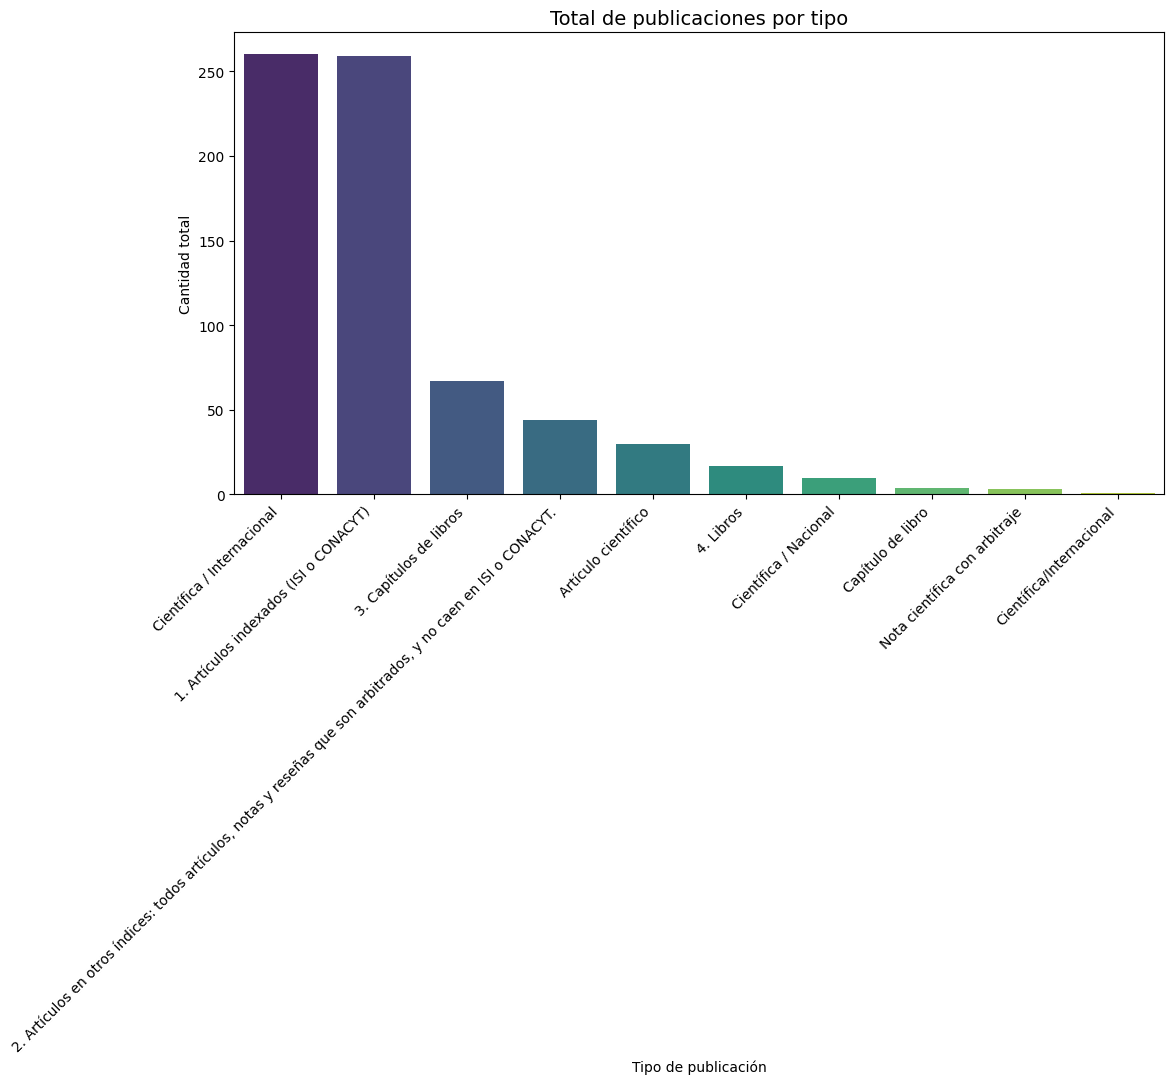

In [10]:
import warnings

warnings.filterwarnings('ignore')

# Calcular total por tipo
total_por_tipo = df_todos_los_tipos.groupby('tipo_publicacion')['cantidad'].sum().reset_index()
total_por_tipo = total_por_tipo.sort_values('cantidad', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=total_por_tipo, x='tipo_publicacion', y='cantidad', palette='viridis')
plt.title('Total de publicaciones por tipo', fontsize=14)
plt.xlabel('Tipo de publicación')
plt.ylabel('Cantidad total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
for tabla in tablas_snii:
    query= f"""
    SELECT  column_name 
    FROM information_schema.columns 
    WHERE table_schema = 'gob_ciencia_y_tecnologia' 
    AND table_name='{tabla}' 
    """
    resultado=pd.read_sql_query(query,con=engine)
    display(resultado)
    if not resultado.empty:
        print('-------------')

,column_name
0,cvu
1,nombre
2,apellido1
3,apellido2
4,nivel
5,categoria
6,inicio_vigencia
7,fin_vigencia
8,area_conocimiento
9,disciplina


-------------


,column_name
0,cvu
1,nombre
2,apellido1
3,apellido2
4,nivel
5,categoria
6,inicio_vigencia
7,fin_vigencia
8,area_conocimiento
9,disciplina


-------------


In [12]:
#tablas_snii  'snii_s1_2025'

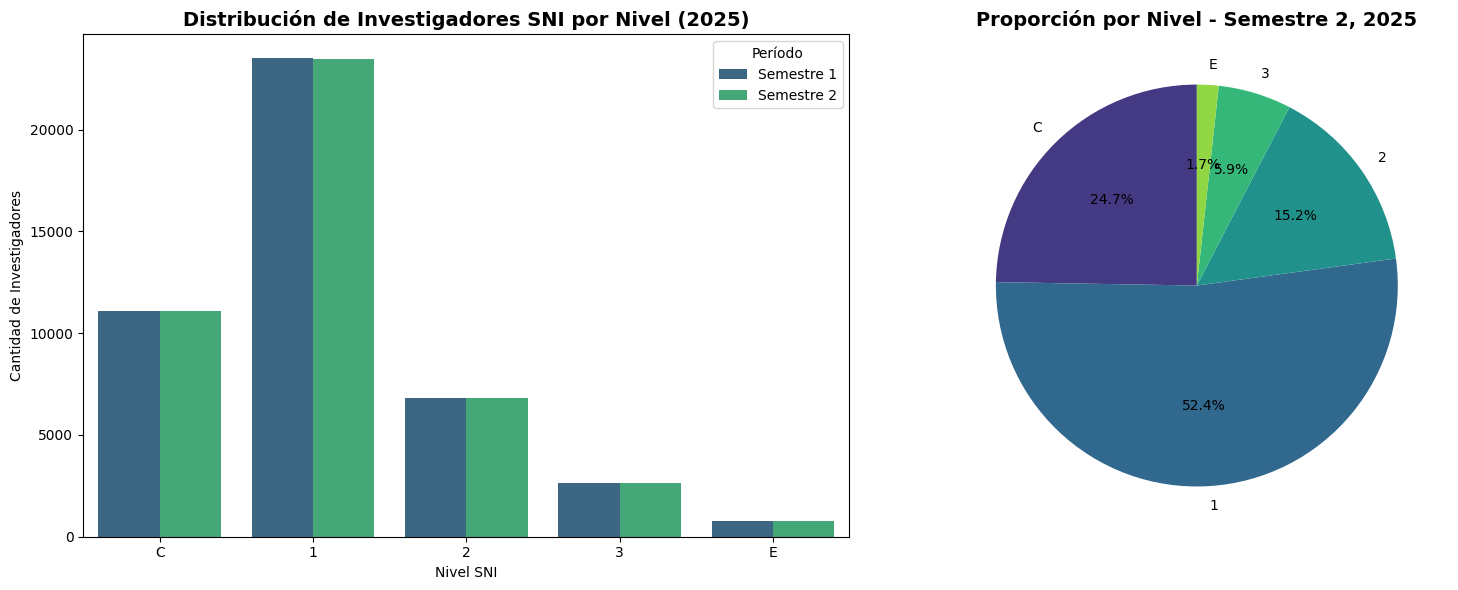

In [13]:
# Celda 6: Query de distribución por nivel SNI
# REEMPLAZA 'investigadores_sni_2025_1' y 'investigadores_sni_2025_2' 
# con los nombres reales de tus tablas 

query_nivel_sni = """
-- Unimos ambos semestres y agregamos etiqueta de semestre
WITH investigadores_total AS (
    SELECT *, 'Semestre 1' as semestre 
    FROM gob_ciencia_y_tecnologia.snii_s1_2025
    UNION ALL
    SELECT *, 'Semestre 2' as semestre 
    FROM gob_ciencia_y_tecnologia.snii_s2_2025
)
SELECT 
    semestre,
    nivel,
    COUNT(*) as total_investigadores,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY semestre), 2) as porcentaje
FROM investigadores_total
WHERE nivel IS NOT NULL
GROUP BY semestre, nivel
ORDER BY semestre, 
    CASE nivel
        WHEN 'C' THEN 1
        WHEN '1' THEN 2
        WHEN '2' THEN 3
        WHEN '3' THEN 4
        WHEN 'E' THEN 5
        ELSE 6
    END;
"""

# Ejecutar query
df_nivel = pd.read_sql_query(query_nivel_sni, con=engine)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras comparativo
sns.barplot(data=df_nivel, x='nivel', y='total_investigadores', 
            hue='semestre', palette='viridis', ax=ax1)
ax1.set_title('Distribución de Investigadores SNI por Nivel (2025)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Nivel SNI')
ax1.set_ylabel('Cantidad de Investigadores')
ax1.legend(title='Período')

#Gráfico de pastel para el semestre más reciente
df_s2 = df_nivel[df_nivel['semestre'] == 'Semestre 2']
ax2.pie(df_s2['total_investigadores'], labels=df_s2['nivel'], autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('viridis', len(df_s2)))
ax2.set_title('Proporción por Nivel - Semestre 2, 2025', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



In [14]:
df_nivel = pd.read_sql_query(query_nivel_sni, con=engine)
df_nivel.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   semestre              10 non-null     str    
 1   nivel                 10 non-null     str    
 2   total_investigadores  10 non-null     int64  
 3   porcentaje            10 non-null     float64
dtypes: float64(1), int64(1), str(2)
memory usage: 452.0 bytes


In [15]:
df_nivel.head()

,semestre,nivel,total_investigadores,porcentaje
0,Semestre 1,C,11083,24.72
1,Semestre 1,1,23499,52.41
2,Semestre 1,2,6828,15.23
3,Semestre 1,3,2640,5.89
4,Semestre 1,E,785,1.75


In [16]:
print("Distribución por Nivel SNI:")
display(df_nivel.pivot_table(values='total_investigadores', 
                             index='nivel', 
                             columns='semestre', 
                             aggfunc='sum'))

Distribución por Nivel SNI:


semestre,Semestre 1,Semestre 2
nivel,,
1,23499,23481
2,6828,6823
3,2640,2632
C,11083,11077
E,785,781


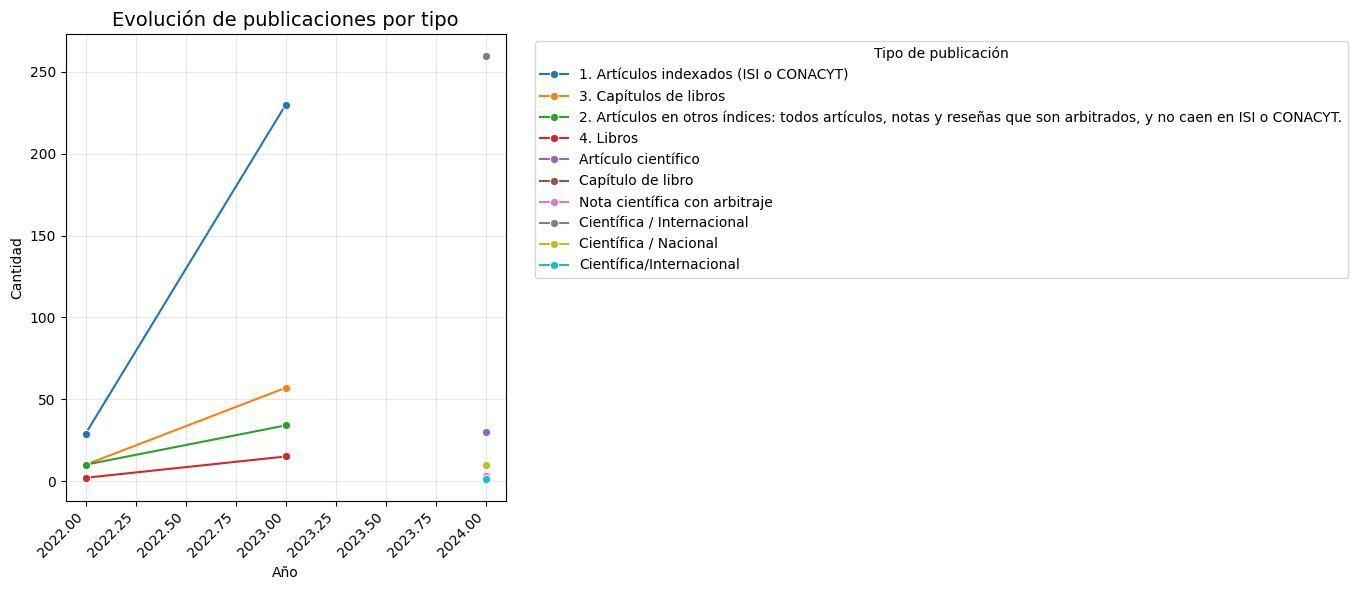

In [17]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_todos_los_tipos, x='anio', y='cantidad', hue='tipo_publicacion', marker='o')
plt.title('Evolución de publicaciones por tipo', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.legend(title='Tipo de publicación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()